# Инжиниринг численных признаков

## Цель работы

Ознакомиться с основными приемами работы с численными атрибутами в датасетах для машинного обучения.

## 1. Загрузка и первоначальное знакомство с данными

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Загрузим датасет с данными о качестве воздуха (PRSA_Data):

In [4]:
prsa_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.2%20numeric%20features/data/PRSA_Data.csv")
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,-1.0,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,-1.0,-1.000000,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,-1.0,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


Основная информация о датасете:

In [5]:
prsa_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  35064 non-null  int64  
 1   No          35064 non-null  int64  
 2   SO2         35064 non-null  float64
 3   NO2         35064 non-null  float64
 4   CO          35064 non-null  float64
 5   O3          35064 non-null  float64
 6   PRES        35064 non-null  float64
 7   RAIN        35064 non-null  float64
 8   wd          35064 non-null  str    
 9   WSPM        35064 non-null  float64
 10  AQI Label   35064 non-null  str    
dtypes: float64(7), int64(2), str(2)
memory usage: 2.9 MB


Численная статистика по данным:

In [6]:
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17531.500000,17532.500000,18.058734,63.236861,1251.121692,45.876835,1010.520250,0.067653,1.500217
std,10122.249256,10122.249256,22.558126,39.109232,1269.033556,54.730861,26.289217,0.896833,1.105382
min,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8765.750000,8766.750000,4.000000,34.000000,500.000000,2.397428,1002.500000,0.000000,0.800000
50%,17531.500000,17532.500000,10.000000,58.000000,900.000000,27.356346,1010.800000,0.000000,1.200000
75%,26297.250000,26298.250000,22.276800,87.000000,1500.000000,69.548316,1019.400000,0.000000,2.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,72.500000,11.200000


## 2. Идентификация ошибочных значений

Заменим отрицательные значения (-1), которые обозначают пропуски, на NaN:

In [7]:
prsa_data[prsa_data == -1] = np.nan
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,NaN,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,NaN,NaN,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,NaN,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


## 3. Визуализация распределения атрибутов

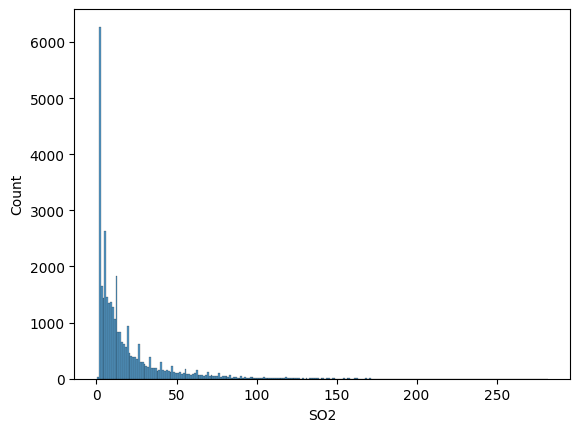

In [8]:
sns.histplot(prsa_data.SO2)
plt.show()

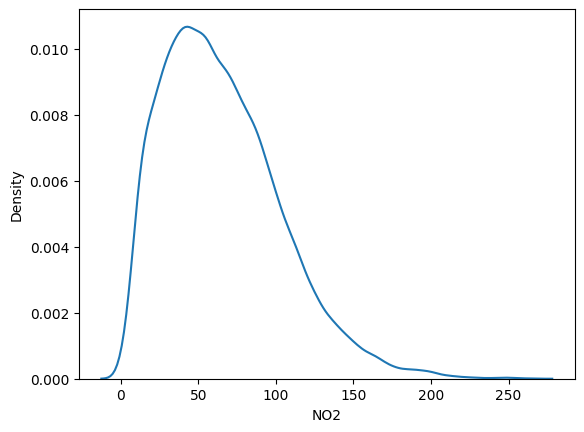

In [9]:
sns.kdeplot(prsa_data.NO2)
plt.show()

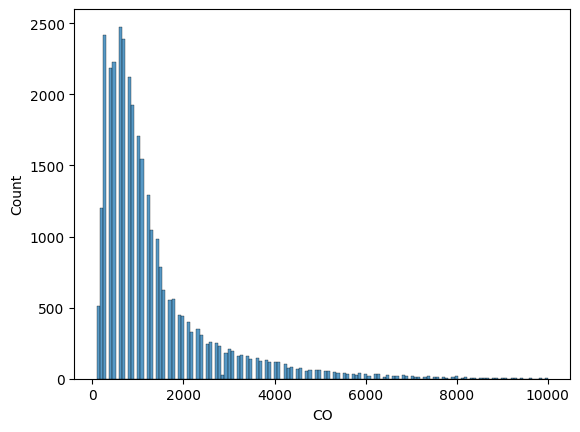

In [10]:
sns.histplot(prsa_data.CO)
plt.show()

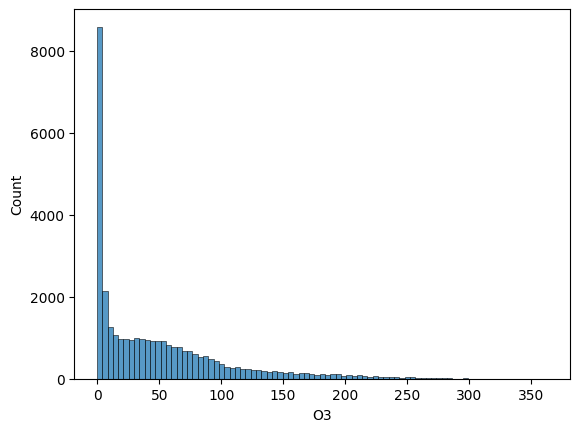

In [11]:
sns.histplot(prsa_data.O3)
plt.show()

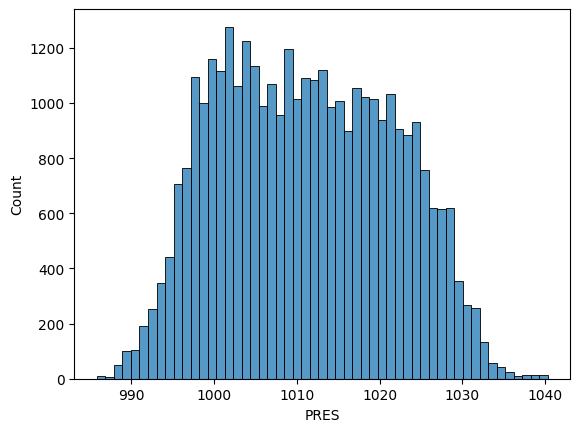

In [12]:
sns.histplot(prsa_data.PRES)
plt.show()

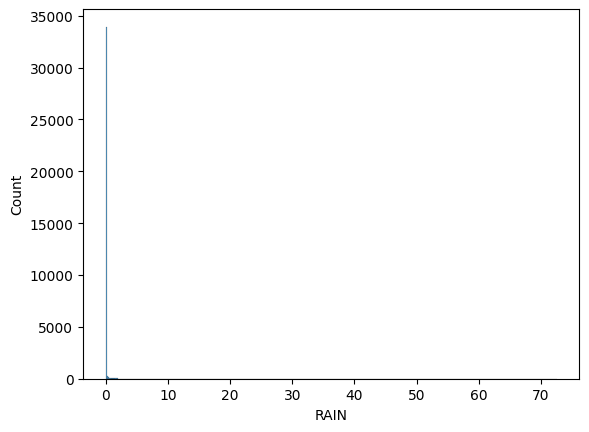

In [13]:
sns.histplot(prsa_data.RAIN)
plt.show()

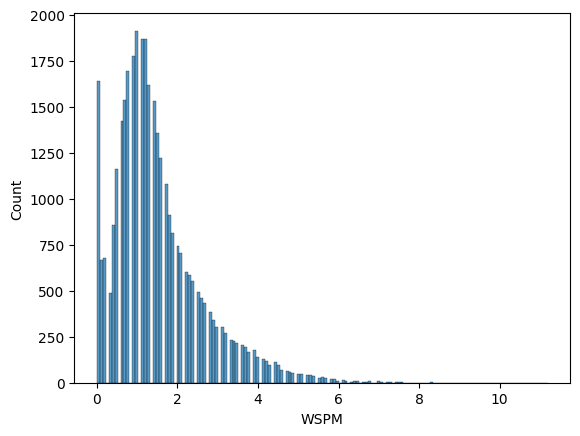

In [14]:
sns.histplot(prsa_data.WSPM)
plt.show()

## 4. Бинаризация атрибутов

Атрибут RAIN имеет крайне неравномерное распределение — подавляющее большинство значений равно 0. Бинаризуем его:

In [15]:
is_rain = np.array(prsa_data.RAIN)
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop(['RAIN'], axis=1, inplace=True)
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN
count,35064.000000,35064.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35050.000000,35044.000000
mean,17531.500000,17532.500000,18.376481,65.258789,1319.353513,48.873754,1011.097536,1.501215,0.040977
std,10122.249256,10122.249256,22.609648,37.996088,1268.114331,55.113576,10.355247,1.104472,0.198240
min,0.000000,1.000000,0.285600,1.642400,100.000000,-0.275160,985.900000,0.000000,0.000000
25%,8765.750000,8766.750000,4.000000,36.000000,500.000000,3.579219,1002.500000,0.800000,0.000000
50%,17531.500000,17532.500000,10.000000,60.000000,900.000000,31.945652,1010.800000,1.200000,0.000000
75%,26297.250000,26298.250000,23.000000,88.000000,1600.000000,72.876079,1019.400000,2.000000,0.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,11.200000,1.000000


## 5. Визуализация связи атрибутов с целевой переменной

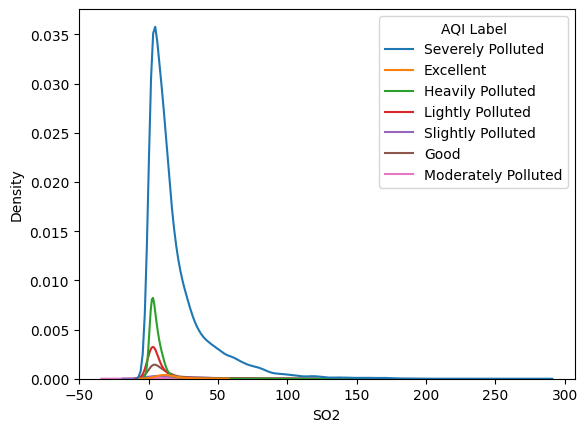

In [16]:
sns.kdeplot(data=prsa_data, x="SO2", hue="AQI Label")
plt.show()

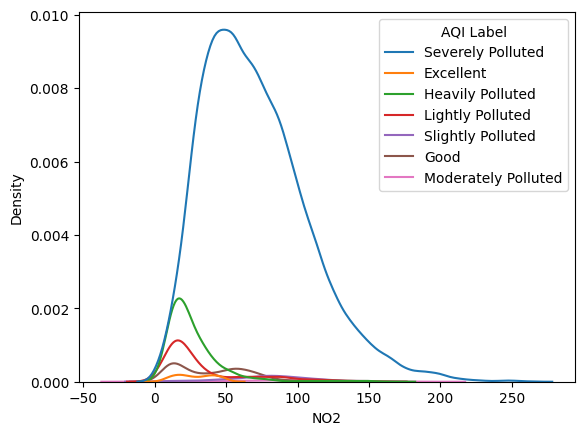

In [17]:
sns.kdeplot(data=prsa_data, x="NO2", hue="AQI Label")
plt.show()

C:\Users\w1nore\AppData\Local\Temp\ipykernel_840\2695507434.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


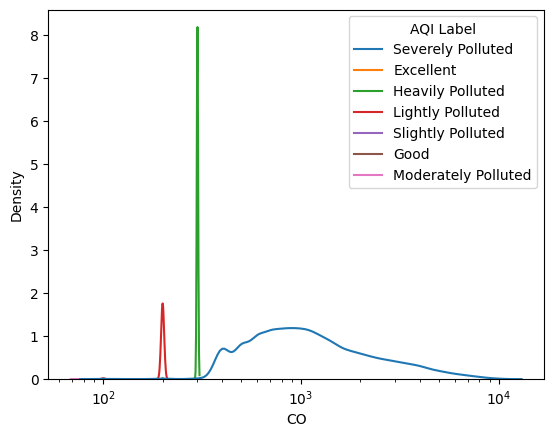

In [18]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)
plt.show()

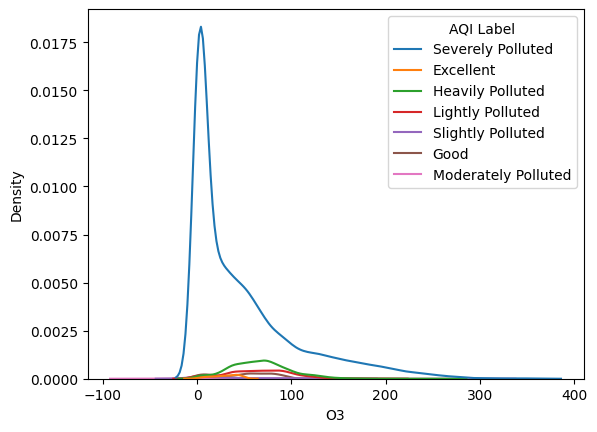

In [19]:
sns.kdeplot(data=prsa_data, x="O3", hue="AQI Label")
plt.show()

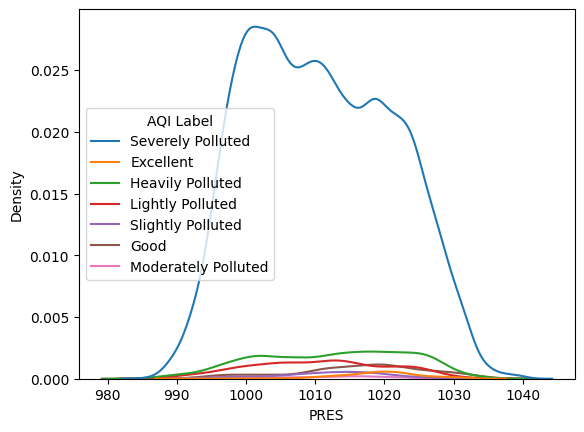

In [20]:
sns.kdeplot(data=prsa_data, x="PRES", hue="AQI Label")
plt.show()

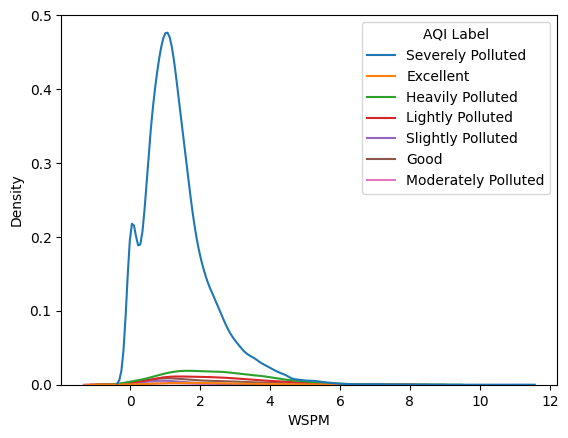

In [21]:
sns.kdeplot(data=prsa_data, x="WSPM", hue="AQI Label")
plt.show()

## 6. Группировка численных значений (дискретизация CO)

In [22]:
bin_ranges = [0, 250, 320, 10000]
bin_names = [1, 2, 3]
prsa_data['CO_bin_custom_label'] = pd.cut(np.array(prsa_data['CO']), 
                                               bins=bin_ranges, labels=bin_names)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,NaN
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


Заполним пропуски в новой категориальной колонке специальным значением 0 (неизвестно):

In [23]:
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].values.add_categories(0)
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].fillna(0).astype(int)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,0
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


## 7. Удаление экстремальных значений (клиппинг PRES)

C:\Users\w1nore\AppData\Local\Temp\ipykernel_840\1843508719.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  prsa_data.PRES[prsa_data.PRES <= 992] = 992
C:\Users\w1nore\AppData\Local\Temp\ipykernel_840\1843508719.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves a

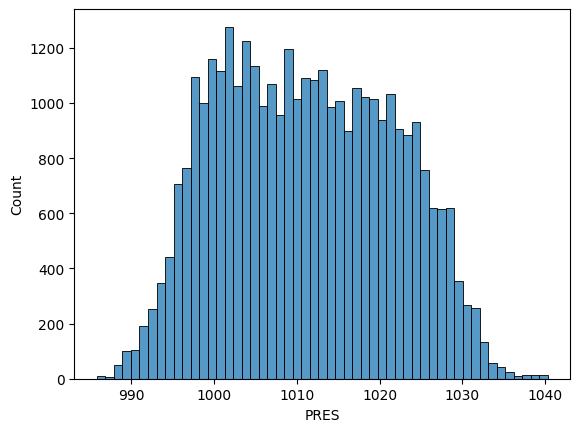

In [24]:
prsa_data.PRES[prsa_data.PRES <= 992] = 992
prsa_data.PRES[prsa_data.PRES >= 1034] = 1034
sns.histplot(prsa_data.PRES)
plt.show()

## 8. Заполнение пропусков

Визуализируем пропущенные значения:

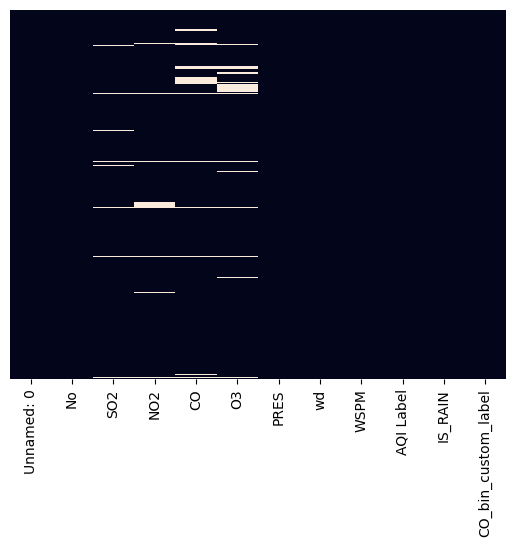

In [25]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)
plt.show()

Удалим объекты, у которых неизвестно значение более двух атрибутов:

In [26]:
undef = prsa_data.isnull().sum(axis=1)
undef[undef >= 2]

3        2
276      3
435      2
459      2
555      2
        ..
34880    4
34883    4
34885    4
35029    2
35030    2
Length: 884, dtype: int64

In [27]:
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)

Повторим визуализацию пропусков:

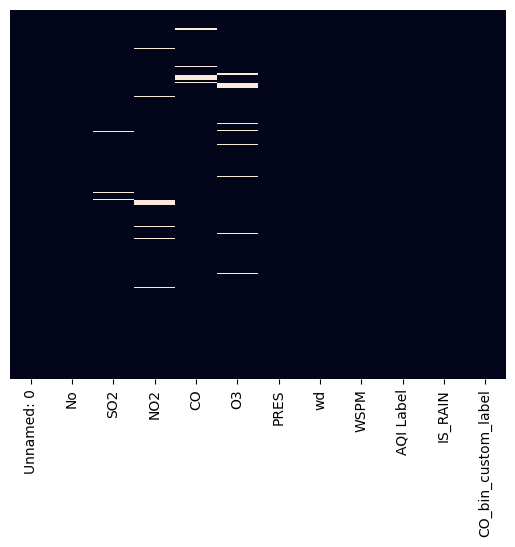

In [28]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)
plt.show()

Количество пропущенных значений по столбцам:

In [29]:
prsa_data.isnull().sum()

Unnamed: 0                0
No                        0
SO2                     281
NO2                     702
CO                     1028
O3                     1300
PRES                      0
wd                        0
WSPM                      0
AQI Label                 0
IS_RAIN                   0
CO_bin_custom_label       0
dtype: int64

Заполним пропуски в SO2 медианой:

In [30]:
prsa_data.SO2 = prsa_data.SO2.fillna(prsa_data.SO2.median())

Заполним пропуски в O3 случайными значениями из существующих:

In [31]:
filler = prsa_data.O3[prsa_data.O3.isna()]
filler = prsa_data.O3[~prsa_data.O3.isna()].sample(n=len(filler)).set_axis(filler.index)
prsa_data.O3 = prsa_data.O3.fillna(filler)

## 9. Округление атрибутов

In [32]:
prsa_data['O3'] = np.array(np.round((prsa_data['O3'])), dtype='int')
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,52,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,10.0,19.0,400.0,55,1023.5,NNW,5.6,Severely Polluted,0.0,3
4,4,5,9.0,NaN,300.0,54,1025.2,N,2.0,Heavily Polluted,0.0,2
5,5,6,8.0,17.0,300.0,54,1025.6,N,3.7,Heavily Polluted,0.0,2


## 10. Логарифмирование атрибутов

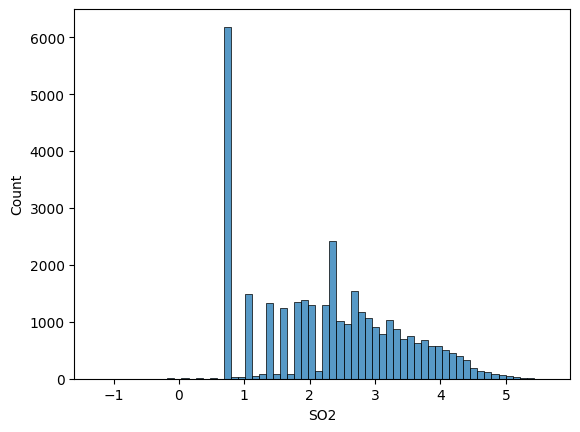

In [33]:
prsa_data.SO2 = np.log(prsa_data.SO2)
sns.histplot(prsa_data.SO2)
plt.show()